### Imports

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install -q snntorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import snntorch as snn
from snntorch import surrogate

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Configuration

In [47]:
SEED = 42
WINDOW = 24
HORIZON = 1

BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


### Load Dataset

In [48]:
df = pd.read_csv("/kaggle/input/datasets/kyleahmurphy/uk-electrical-load/House_2.csv")

df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time")

# Select all relevant columns: Time, Aggregate, and Appliance1-9
cols_to_keep = ["Time", "Aggregate"] + [f"Appliance{i}" for i in range(1, 10)]
df = df[cols_to_keep].dropna()

# Resample all columns to 15-minute intervals
df = df.set_index("Time").resample("15min").mean().dropna().reset_index()

print(df.shape)
print(df.columns.tolist())
print(df.head())

(45093, 11)
['Time', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']
                 Time   Aggregate  Appliance1  Appliance2  Appliance3  \
0 2013-09-17 22:00:00  713.370968   86.580645         0.0         0.0   
1 2013-09-17 22:15:00  502.266667   75.340000         0.0         0.0   
2 2013-09-17 22:30:00   91.666667    1.006667         0.0         0.0   
3 2013-09-17 22:45:00   60.344371    1.000000         0.0         0.0   
4 2013-09-17 23:00:00   60.161074    1.000000         0.0         0.0   

   Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  
0         0.0         0.0         0.0         0.0         0.0         0.0  
1         0.0         0.0         0.0         0.0         0.0         0.0  
2         0.0         0.0         0.0         0.0         0.0         0.0  
3         0.0         0.0         0.0         0.0         0.0         0.0  
4         0.0        

In [49]:
df["Target"] = df["Aggregate"].shift(-HORIZON)
df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.shape)

                 Time   Aggregate  Appliance1  Appliance2  Appliance3  \
0 2013-09-17 22:00:00  713.370968   86.580645         0.0         0.0   
1 2013-09-17 22:15:00  502.266667   75.340000         0.0         0.0   
2 2013-09-17 22:30:00   91.666667    1.006667         0.0         0.0   
3 2013-09-17 22:45:00   60.344371    1.000000         0.0         0.0   
4 2013-09-17 23:00:00   60.161074    1.000000         0.0         0.0   

   Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  \
0         0.0         0.0         0.0         0.0         0.0         0.0   
1         0.0         0.0         0.0         0.0         0.0         0.0   
2         0.0         0.0         0.0         0.0         0.0         0.0   
3         0.0         0.0         0.0         0.0         0.0         0.0   
4         0.0         0.0         0.0         0.0         0.0         0.0   

       Target  
0  502.266667  
1   91.666667  
2   60.344371  
3   60.161074  
4  134.073826  
(4

In [50]:

# Add hour features
df["hour"] = df["Time"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

print("Columns:", df.columns.tolist())
print(df.head())


Columns: ['Time', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9', 'Target', 'hour', 'hour_sin', 'hour_cos']
                 Time   Aggregate  Appliance1  Appliance2  Appliance3  \
0 2013-09-17 22:00:00  713.370968   86.580645         0.0         0.0   
1 2013-09-17 22:15:00  502.266667   75.340000         0.0         0.0   
2 2013-09-17 22:30:00   91.666667    1.006667         0.0         0.0   
3 2013-09-17 22:45:00   60.344371    1.000000         0.0         0.0   
4 2013-09-17 23:00:00   60.161074    1.000000         0.0         0.0   

   Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  \
0         0.0         0.0         0.0         0.0         0.0         0.0   
1         0.0         0.0         0.0         0.0         0.0         0.0   
2         0.0         0.0         0.0         0.0         0.0         0.0   
3         0.0         0.0         0.0         0.0     

### Preprocessing

In [51]:
# Chronological split
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (31564, 15)
Validation: (6764, 15)
Test: (6764, 15)


In [52]:
# 12 input features: Aggregate + Appliance1-9 + hour_sin + hour_cos
feature_cols = ["Aggregate"] + [f"Appliance{i}" for i in range(1, 10)] + ["hour_sin", "hour_cos"]

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print(f"Features ({len(feature_cols)}): {feature_cols}")
print("Train mean:", train_scaled.mean(axis=0))
print("Train std:", train_scaled.std(axis=0))
print("Scaled shape:", train_scaled.shape)

Features (12): ['Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9', 'hour_sin', 'hour_cos']
Train mean: [ 1.44071522e-17  1.13456323e-16 -9.90491711e-18 -5.67281616e-17
  1.44071522e-17  7.20357608e-18  5.40268206e-18 -1.44071522e-17
 -5.04250326e-17 -1.98098342e-17  3.66932157e-17  1.96972783e-17]
Train std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Scaled shape: (31564, 12)


In [53]:
def create_sequences(data, window=WINDOW):
    X = []
    y = []

    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window, 0])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (31540, 24, 12)
y_train: (31540,)
X_val: (6740, 24, 12)
y_val: (6740,)
X_test: (6740, 24, 12)
y_test: (6740,)


In [54]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(X_train.shape, y_train.shape)

torch.Size([31540, 24, 12]) torch.Size([31540, 1])


In [55]:
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 247
Validation batches: 53
Test batches: 53


### RSNN Model

In [56]:
class RSNNForecaster(nn.Module):
    def __init__(self, input_size=12):
        super().__init__()

        self.fc_in = nn.Linear(input_size, 32)

        self.rlif = snn.RLeaky(
            beta=0.9,
            linear_features=32,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.output = nn.Linear(32, 1)

    def forward(self, x):
        spk, mem = self.rlif.init_rleaky()

        for t in range(x.size(1)):
            cur = self.fc_in(x[:, t, :])
            spk, mem = self.rlif(cur, spk=spk, mem=mem)

        # Use continuous membrane state for regression
        return self.output(mem)
        
model = RSNNForecaster(input_size=12).to(DEVICE)
print(model)

RSNNForecaster(
  (fc_in): Linear(in_features=12, out_features=32, bias=True)
  (rlif): RLeaky(
    (recurrent): Linear(in_features=32, out_features=32, bias=True)
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [62]:
def weighted_mse(pred, target):
    weights = 1.0 + 2.0 * torch.clamp(target.abs(), max=3.0)
    return (weights * (pred - target) ** 2).mean()

criterion = nn.MSELoss()

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

### Training Loop

In [63]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch + 1:02d}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 01/30 | Train: 0.7807 | Val: 0.9607
Epoch 02/30 | Train: 0.7585 | Val: 0.9843
Epoch 03/30 | Train: 0.7594 | Val: 0.9822
Epoch 04/30 | Train: 0.7593 | Val: 1.0213
Epoch 05/30 | Train: 0.7576 | Val: 0.9726
Epoch 06/30 | Train: 0.7560 | Val: 0.9676
Epoch 07/30 | Train: 0.7557 | Val: 1.0128
Epoch 08/30 | Train: 0.7580 | Val: 0.9475
Epoch 09/30 | Train: 0.7568 | Val: 0.9758
Epoch 10/30 | Train: 0.7517 | Val: 0.9515
Epoch 11/30 | Train: 0.7566 | Val: 0.9526
Epoch 12/30 | Train: 0.7543 | Val: 0.9974
Epoch 13/30 | Train: 0.7546 | Val: 0.9531
Epoch 14/30 | Train: 0.7580 | Val: 0.9768
Epoch 15/30 | Train: 0.7538 | Val: 0.9676
Epoch 16/30 | Train: 0.7514 | Val: 0.9782
Epoch 17/30 | Train: 0.7495 | Val: 0.9635
Epoch 18/30 | Train: 0.7519 | Val: 0.9778
Epoch 19/30 | Train: 0.7496 | Val: 0.9664
Epoch 20/30 | Train: 0.7483 | Val: 0.9707
Epoch 21/30 | Train: 0.7550 | Val: 0.9681
Epoch 22/30 | Train: 0.7518 | Val: 0.9777
Epoch 23/30 | Train: 0.7512 | Val: 0.9738
Epoch 24/30 | Train: 0.7497 | Val:

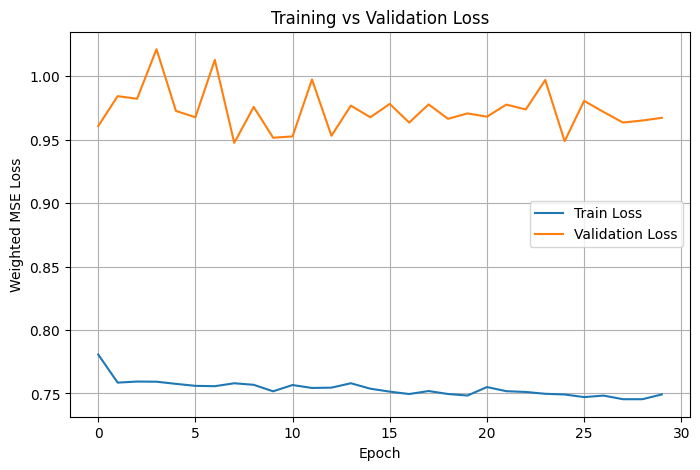

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Weighted MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation

In [65]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)

        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions).flatten()
actuals = np.concatenate(actuals).flatten()

# Inverse transform: create dummy arrays with 12 features
# Put predictions/actuals in first column (Aggregate), zeros elsewhere
n_samples = len(predictions)
predictions_full = np.zeros((n_samples, len(feature_cols)))
actuals_full = np.zeros((n_samples, len(feature_cols)))

predictions_full[:, 0] = predictions
actuals_full[:, 0] = actuals

predictions_watts = scaler.inverse_transform(predictions_full)[:, 0]
actuals_watts = scaler.inverse_transform(actuals_full)[:, 0]

mae = mean_absolute_error(actuals_watts, predictions_watts)
rmse = np.sqrt(mean_squared_error(actuals_watts, predictions_watts))
r2 = r2_score(actuals_watts, predictions_watts)

print(f"MAE:  {mae:.2f} W")
print(f"RMSE: {rmse:.2f} W")
print(f"R²:   {r2:.4f}")

MAE:  341.03 W
RMSE: 694.60 W
R²:   0.3207


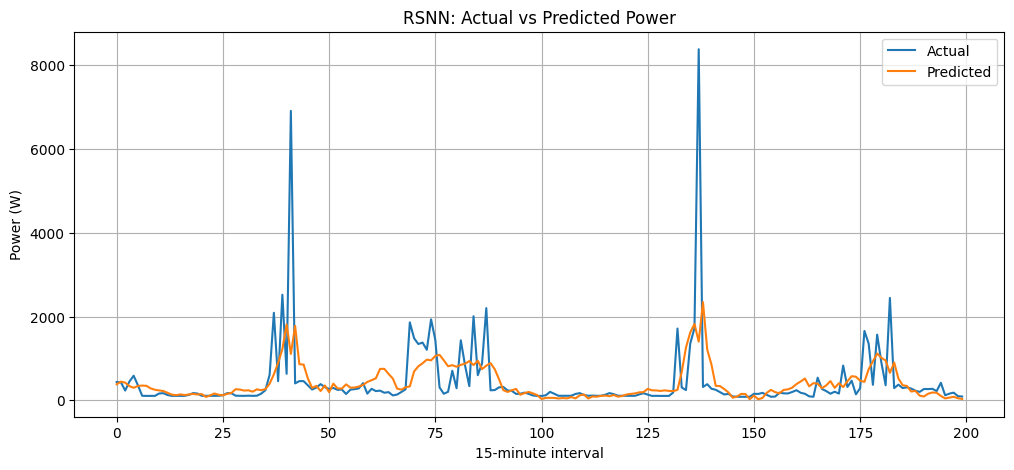

In [69]:
points = 200

plt.figure(figsize=(12, 5))
plt.plot(actuals_watts[:points], label="Actual")
plt.plot(predictions_watts[:points], label="Predicted")
plt.xlabel("15-minute interval")
plt.ylabel("Power (W)")
plt.title("RSNN: Actual vs Predicted Power")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "window": WINDOW,
    "input_size": 12,
    "learning_rate": LEARNING_RATE,
    "epoch": epoch,
}, "rsnn_forecaster_checkpoint.pth")